# Not included in manuscript
# Monthly sensitivity tests

### Imports

In [1]:
import pop_tools
import xarray as xr
import numpy as np
import cftime
import xesmf as xe
import cmocean
import matplotlib.pyplot as plt
import matplotlib.collections as mcollections
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
from scipy.signal import coherence, csd
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks
from scipy.stats import linregress
import scipy.stats as stats
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import xesmf as xe
import pop_tools
import cftime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import gaussian_kde

import warnings
warnings.filterwarnings('ignore')

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/pop_tools/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
import processing_utils as proc_utils
import cesm2_lens_utils
import analysis_funcs as afuncs
import stc_funcs as stcfuncs

### Functions

In [3]:
def truncate_after_first_exit_equator(lon_data, lat_data, z_data):
    lon_data_truncated = lon_data.copy()
    lat_data_truncated = lat_data.copy()
    z_data_truncated = z_data.copy()
    
    # Define equatorial region boundaries
    lat_min, lat_max = -1, 1     # 2°S to 2°N
    lon_min, lon_max = 140, 305   # 200° to 280° longitude
    
    for i in range(lon_data.sizes['trajectory']):
        lon_traj = lon_data.isel(trajectory=i).values
        lat_traj = lat_data.isel(trajectory=i).values
        
        # Track if we've entered the equatorial region at least once
        has_entered_equator = False
        first_exit_index = None
        
        for j in range(len(lat_traj)):
            # Check if current point is in equatorial region
            in_equator = ((lat_traj[j] >= lat_min) & (lat_traj[j] <= lat_max) & 
                          (lon_traj[j] >= lon_min) & (lon_traj[j] <= lon_max))
            
            if in_equator:
                has_entered_equator = True
            elif has_entered_equator and first_exit_index is None:
                # We've entered equator before and now we're exiting for the first time
                first_exit_index = j
                break
        # Truncate after first exit point
        if first_exit_index is not None:
            lon_data_truncated[i, first_exit_index:] = np.nan
            lat_data_truncated[i, first_exit_index:] = np.nan
            z_data_truncated[i, first_exit_index:] = np.nan
    return lon_data_truncated, lat_data_truncated, z_data_truncated        

In [4]:
def get_region_lonlat(lat_data, lon_data, region_lat_min, region_lat_max, region_lon_min, region_lon_max):
    index_min = 0
    index_max = 400
    
    in_region_mask = (
        (lat_data[index_min:index_max, 0] >= region_lat_min) & 
        (lat_data[index_min:index_max, 0] <= region_lat_max) &
        (lon_data[index_min:index_max, 0] >= region_lon_min) & 
        (lon_data[index_min:index_max, 0] <= region_lon_max)
    )
    
    region_indices = np.where(in_region_mask)[0] + index_min
    return region_indices

In [5]:
def calc_density(lon_data, lat_data, z_data, lat_min, lat_max, lon_min, lon_max, timestart, timeend):
    
    lon_trunc,lat_trunc, z_trunc = truncate_after_first_exit_equator(#truncate_after_exit_equator(#truncate_lonlatz(
        lon_data, lat_data, z_data)

    region_idx = get_region_lonlat(lat_trunc, lon_trunc, lat_min, lat_max, lon_min, lon_max)
    # region_idx_p1 = get_region_lonlat(lat_trunc, lon_trunc, -35, -30, 220, 240)
    # region_idx_p2 = get_region_lonlat(lat_trunc, lon_trunc, -40, -35, 220,240)
    
    lons_points = lon_trunc[region_idx, timestart:timeend].data.flatten()
    lats_points = lat_trunc[region_idx, timestart:timeend].data.flatten()
    
    f_xi, f_yi, f_zi = calc_density_sh(lons_points, lats_points)
    
    da = xr.DataArray(f_zi, dims=['y', 'x'],
        coords={'lon': (['y', 'x'], f_xi),'lat': (['y', 'x'], f_yi)},name='density')
    
    # da_nan = xr.where(da <= 0.000001, np.nan, da)
    # return da_nan, region_idx, lon_trunc,lat_trunc, z_trunc
    return da, region_idx, lon_trunc,lat_trunc, z_trunc

In [7]:
def calc_density_sh(lons, lats, gridsize=100, bw_method=None, lon_bounds=(110, 305), lat_bounds=(-50, 50)):
    """
    Calculate 2D Gaussian KDE density with fixed grid bounds.
    """
    # Remove NaN values
    valid_mask = ~np.isnan(lons) & ~np.isnan(lats)
    lons_clean = lons[valid_mask]
    lats_clean = lats[valid_mask]
    
    if len(lons_clean) == 0:
        raise ValueError("No valid data points for KDE calculation")
    
    # Use fixed bounds instead of data-derived bounds
    xi = np.linspace(lon_bounds[0], lon_bounds[1], gridsize)
    yi = np.linspace(lat_bounds[0], lat_bounds[1], gridsize)
    f_xi, f_yi = np.meshgrid(xi, yi)
    
    # Calculate Gaussian KDE
    coordinates = np.vstack([lons_clean, lats_clean])
    kde = gaussian_kde(coordinates, bw_method=bw_method)
    
    # Evaluate KDE on the fixed grid
    grid_coords = np.vstack([f_xi.ravel(), f_yi.ravel()])
    f_zi = kde(grid_coords).reshape(f_xi.shape)
    
    return f_xi, f_yi, f_zi

In [8]:
def truncate_lonlatz(lon_data, lat_data, z_data):
    lon_data_truncated = lon_data.copy()
    lat_data_truncated = lat_data.copy()
    z_data_truncated = z_data.copy()
    
    # lon_min, lon_max = 260, 291
    lon_min, lon_max = 260, 280#290, 291 #260, 280
    lat_min, lat_max = -1, 1
    
    for i in range(lon_data.sizes['trajectory']):
        lon_traj = lon_data.isel(trajectory=i).values
        lat_traj = lat_data.isel(trajectory=i).values
        
        in_target_region = (lon_traj >= lon_min) & (lon_traj <= lon_max) & (lat_traj >= lat_min) & (lat_traj <= lat_max)
        
        # Find first occurrence in target region
        region_indices = np.where(in_target_region)[0]
        
        if len(region_indices) > 0:
            first_in_region = region_indices[0]
            # Set all observations after entering region to NaN
            lon_data_truncated[i, first_in_region+1:] = np.nan
            lat_data_truncated[i, first_in_region+1:] = np.nan
            z_data_truncated[i, first_in_region+1:] = np.nan

    return lon_data_truncated, lat_data_truncated, z_data_truncated

### Analysis

In [15]:
da_traj_list = []
for month_ind in range(0, 12):
    file_path = '/glade/derecho/scratch/cassiacai/particle_trajectories/particle_trajectories_fosi_month{}_SH_startingat50m_1958_1977.zarr'.format(
        month_ind)
    print(month_ind)

    traj_pt = xr.open_zarr(file_path)
    traj_time, traj_lon, traj_lat, traj_z = stcfuncs.compute_data(traj_pt)
    
    da_traj, region_idx_traj,lon_trunc_traj,lat_trunc_traj, z_trunc_traj = calc_density(
       lon_data=traj_lon, lat_data=traj_lat, z_data=traj_z, 
        lat_min=-40, lat_max=-30, lon_min=220, lon_max=275,
        timestart=0, timeend=244)
    da_traj_list.append(da_traj)

1
2
3
4
5
6
7
8
9
10
11


In [16]:
traj_list = xr.concat(da_traj_list, dim='ens')

In [17]:
lon_data= lon_trunc_traj[:, 0:244]
lat_data= lat_trunc_traj[:, 0:244]
region_idx = region_idx_traj

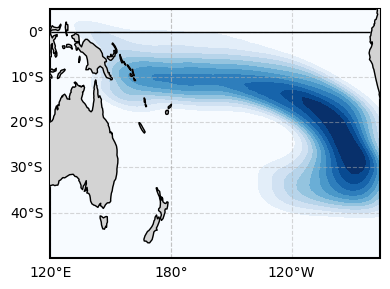

In [26]:
fig, ax = plt.subplots(figsize=(4, 3),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -5, 50], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

####### INITIAL LOCATIONS
# ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
#            s=0.5, c='k', marker='o', edgecolor='k', zorder=100,transform=ccrs.PlateCarree())

# #### CONTOURF AND CONTOUR
contourf_plot = traj_list.isel(ens=0).plot.contourf(
    x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
    levels=11, vmax=60e-5, vmin=0, alpha=1) # 6

#### TITLE
# plt.title('LENS: Dec', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.tight_layout()
plt.show()